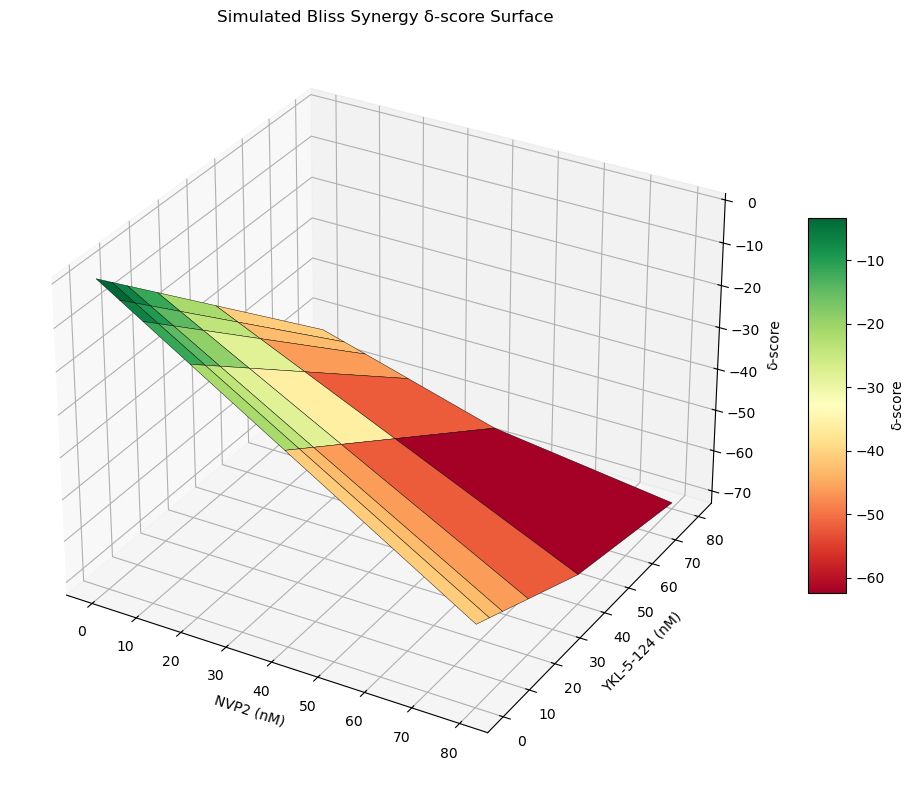

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Simulated drug concentrations (in nM)
nvp2_doses = np.array([0, 5, 10, 20, 40, 80])
ykl_doses = np.array([0, 5, 10, 20, 40, 80])

# Create dose-response meshgrid
nvp2_grid, ykl_grid = np.meshgrid(nvp2_doses, ykl_doses, indexing='ij')

# Simulate observed % viability for each dose combo
# Here we simulate a surface where viability decreases with dose
observed = 100 - (np.outer(nvp2_doses, np.ones_like(ykl_doses)) +
                  np.outer(np.ones_like(nvp2_doses), ykl_doses)) / 1.5
observed = np.clip(observed, 0, 100)  # Cap at 0–100%

# Compute expected % viability under Bliss independence model:
# E = A + B - A*B / 100
single_nvp2 = 100 - nvp2_doses / 1.5
single_ykl = 100 - ykl_doses / 1.5
expected = np.zeros_like(observed)

for i in range(len(nvp2_doses)):
    for j in range(len(ykl_doses)):
        a = single_nvp2[i]
        b = single_ykl[j]
        expected[i, j] = a + b - a * b / 100

# Calculate δ-score = observed - expected
delta_score = observed - expected

# Plot 3D surface
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotting the surface with color mapping
surf = ax.plot_surface(nvp2_grid, ykl_grid, delta_score,
                       cmap='RdYlGn', edgecolor='k', linewidth=0.3)

# Axis labels
ax.set_xlabel('NVP2 (nM)')
ax.set_ylabel('YKL-5-124 (nM)')
ax.set_zlabel('δ-score')
ax.set_title('Simulated Bliss Synergy δ-score Surface')

# Add color bar for reference
fig.colorbar(surf, shrink=0.5, aspect=10, label='δ-score')

plt.tight_layout()
plt.show()
